# [Chroma with image](https://colab.research.google.com/drive/1iIZBCvA1HIAIToxCbyKZLt_5XG7VjhJs?usp=sharing#scrollTo=jbwLWGiDElhM)

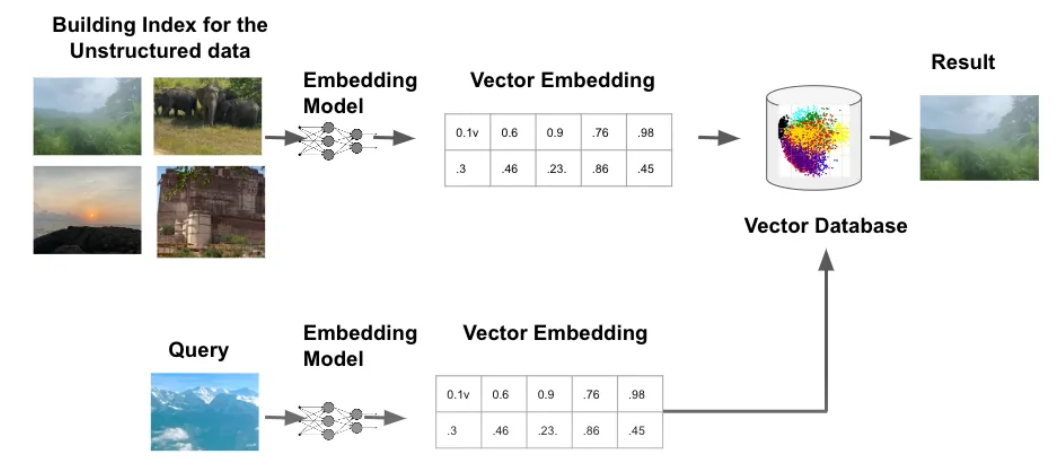

## Load Images

In [ ]:
from PIL import Image

IMAGE_DATA_PATH = "./data/images/"
img = Image.open(IMAGE_DATA_PATH+"pizza/194643.jpg")
img

## [Vector DB - Chroma](https://www.trychroma.com/)

In [ ]:
import chromadb

client = chromadb.PersistentClient(
    path="./image_db" # 영구 저장 경로 지정
)

collection = client.create_collection("foods")

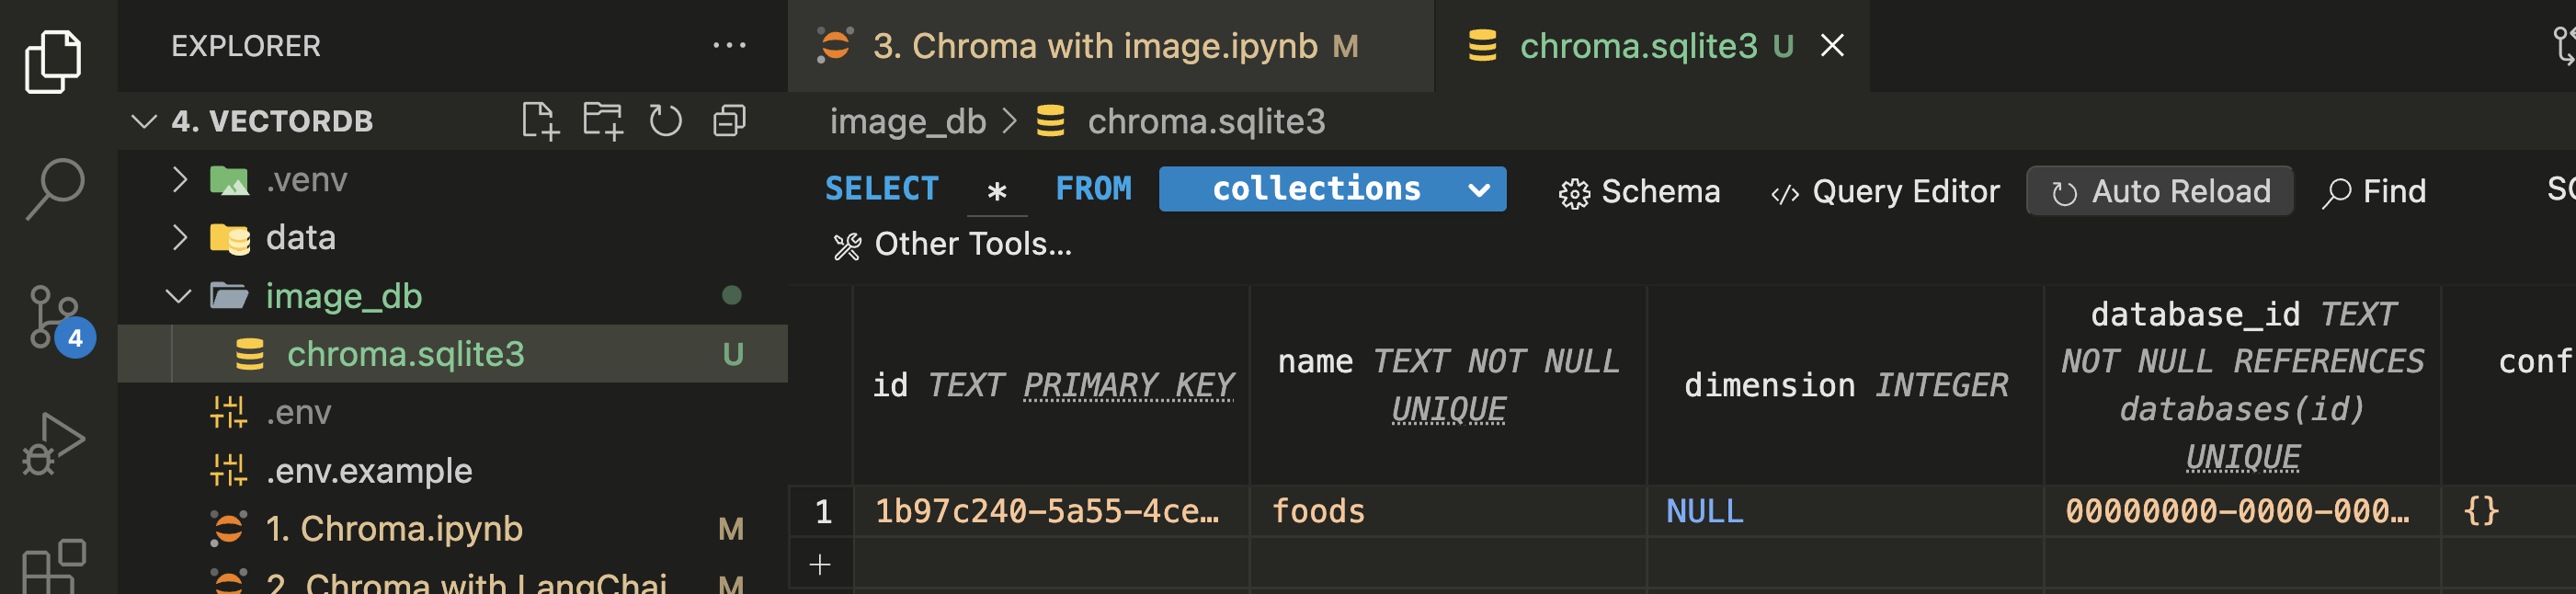

## [Vectorizer Model](https://huggingface.co/facebook/dino-vits16)

### [HuggingFace API Key](https://huggingface.co/settings/tokens)

In [ ]:
from dotenv import load_dotenv 

load_dotenv()

### Model

In [ ]:
import torch 

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

In [ ]:
from transformers import ViTFeatureExtractor, ViTModel

# 사용할 모델 이름 (DINO 기반 Vision Transformer Small/16)
model_name = 'facebook/dino-vits16'

# 모델과 관련 파일(가중치, 설정 파일 등)을 저장할 캐시 디렉토리
cache_dir = "./model_cache"

# ============================================
# 1. 이미지 전처리를 담당하는 Feature Extractor 로드
# ============================================
# - ViT 모델이 입력으로 받을 수 있도록 이미지 크기 변경, 정규화 등을 수행한다.
# - HuggingFace Hub에서 모델의 feature_extractor 설정을 다운로드해 사용한다.
feature_extractor = ViTFeatureExtractor.from_pretrained(
    model_name,
    cache_dir=cache_dir   # 다운로드한 파일을 저장할 로컬 캐시 위치
)

# ============================================
# 2. ViT 모델(백본 CNN/Transformer) 로드
# ============================================
# - DINO 학습 방식으로 Self-supervised 학습된 Vision Transformer 모델
# - from_pretrained(): 사전 학습된 가중치를 불러온다.
# - to(device): 모델을 GPU 또는 CPU로 이동
# ============================================
model = ViTModel.from_pretrained(
    model_name,
    cache_dir=cache_dir
).to(device)


### 이미지 임베딩 테스트

In [ ]:
from PIL import Image

IMAGE_DATA_PATH = "./data/images/"
img = Image.open(IMAGE_DATA_PATH+"pizza/194643.jpg")
img

In [ ]:
# ============================================================
# 1. 입력 이미지를 ViT 입력 형식으로 변환 (전처리)
# ============================================================
# - feature_extractor(images=img): 이미지 크기 조정, 정규화 등 수행
# - return_tensors="pt": PyTorch 텐서 형태로 반환
# - .to(device): GPU 또는 CPU 디바이스로 텐서 이동
img_tensor = feature_extractor(
    images=img,
    return_tensors="pt"
).to(device)

# ============================================================
# 2. 전처리된 이미지 텐서를 ViT 모델에 입력하여 feature 추출
# ============================================================
# - model(**img_tensor): 모델에 입력 (pixel_values 등 키워드를 자동 전달)
# - outputs: 마지막 hidden states, pooler_output 등을 포함하는 객체
outputs = model(**img_tensor)

# ============================================================
# 3. 최종 이미지 임베딩 추출
# ============================================================
# - outputs.pooler_output: CLS 토큰 기반의 전체 이미지 대표 벡터(임베딩)
# - detach(): 그래프 분리 (학습/미분 불필요)
# - cpu(): GPU → CPU로 이동
# - numpy(): 넘파이 배열로 변환
# - squeeze(): (1, D) → (D) 형태로 차원 축소
embedding = outputs.pooler_output.detach().cpu().numpy().squeeze()


In [ ]:
print(f"임베팅 크기: {embedding.shape}")

In [ ]:
embedding[:3]

### 전체 이미지 임베딩

In [ ]:
from glob import glob

img_list = sorted(glob(IMAGE_DATA_PATH+"*/*.jpg"))

print(f"전체 이미지 수: {len(img_list)}")

In [ ]:
# 이미지 path 확인 
img_list[:5]

In [ ]:
from tqdm import tqdm

embeddings = [] # Vector DB에 저장할 데이터
metadatas = []  # Vector DB에 저장된 데이터의 참고자료
ids = []        # Vector DB에 저장된 데이터를 식별할 데이터

for i, img_path in enumerate(tqdm(img_list)):
    # 이미지 로드
    img = Image.open(img_path)
    # 이미지 메타 데이터 추출
    cls = img_path.split(".")[-1]

    # 이미지를 벡터 데이터(Pytorch)로 변환
    img_tensor = feature_extractor(images=img, return_tensors="pt").to(device)
    outputs = model(**img_tensor)

    # 벡터 데이터(Pytorch)를 파이썬 리스트로 변환
    embedding = outputs.pooler_output.detach().cpu().numpy().squeeze().tolist()

    # 해당 이미지 벡터 데이터를 리스트에 저장
    embeddings.append(embedding)
    # 메타데이터 저장
    metadatas.append({
        "uri": img_path,
        "name": cls
    })
    # Vector DB에서 사용할 유니크한 id 생성 및 저장
    ids.append(str(i)+cls)

print("Done!")

### 벡터 데이터 저장 to Vector DB

In [ ]:
collection.add(
    embeddings=embeddings,
    metadatas=metadatas,
    ids=ids,
)

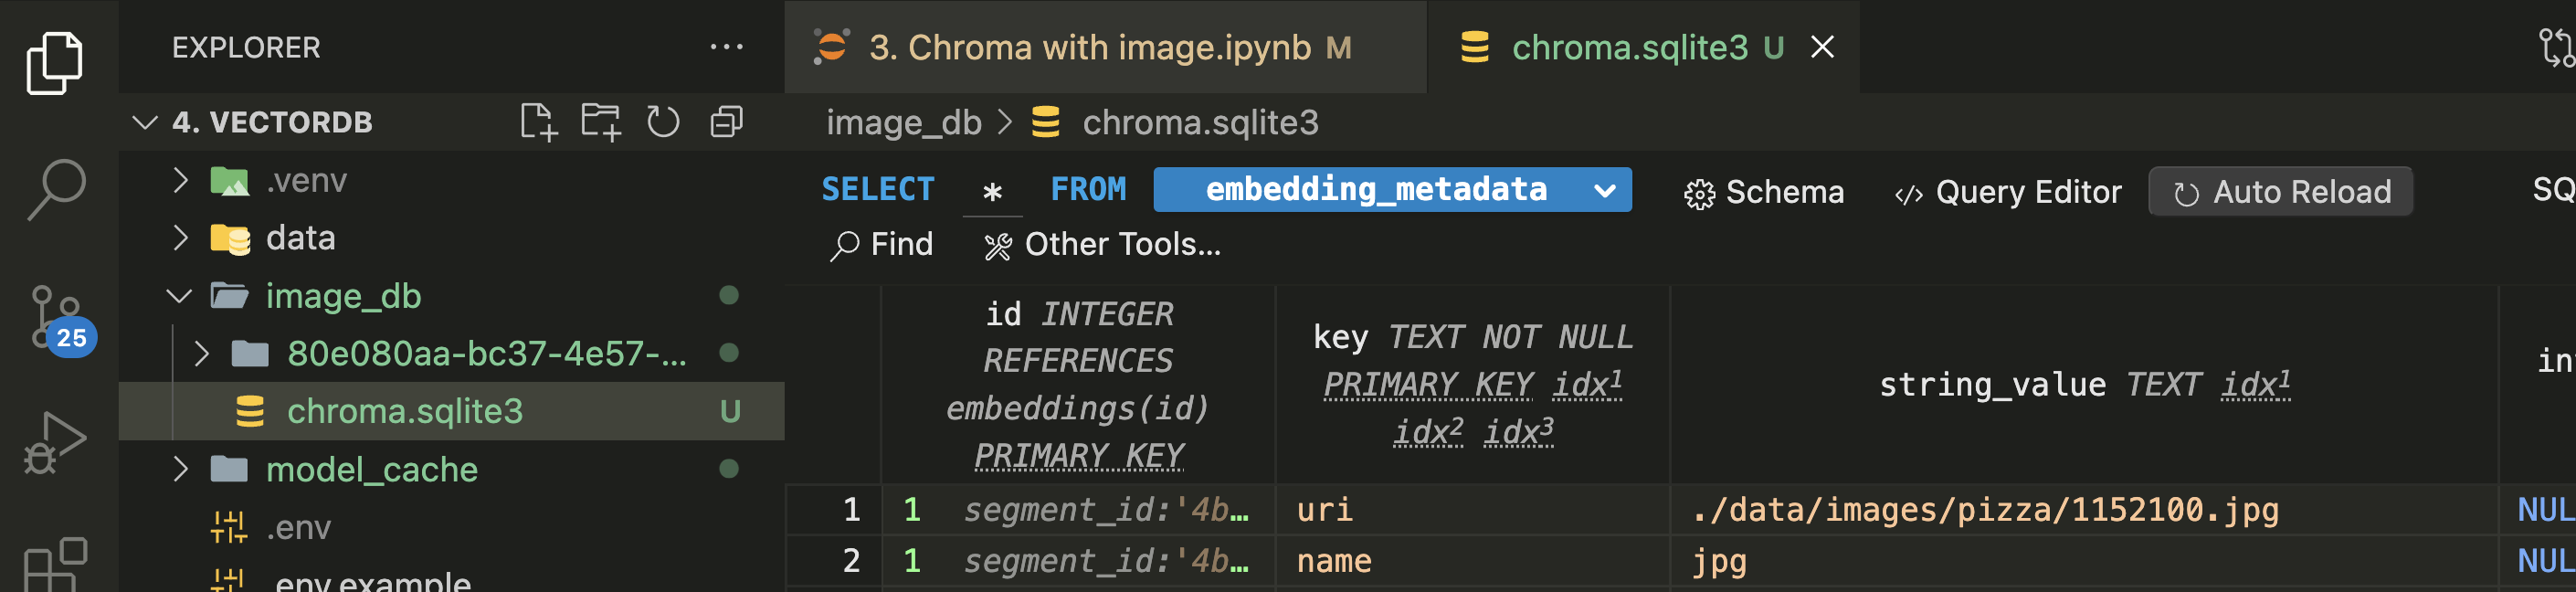

## 조회 테스트

### 이미지 로드 

In [ ]:
from PIL import Image

test_img = Image.open(IMAGE_DATA_PATH+"steak/296375.jpg")
test_img

### 이미지 임베딩

In [ ]:
test_img_tensor = feature_extractor(images=test_img, return_tensors="pt").to(device)
test_outputs = model(**test_img_tensor)

test_embedding = test_outputs.pooler_output.detach().cpu().numpy().squeeze()
print(f"변환된 임베딩 크기: {test_embedding.shape}")

### 유사한 이미지 조회

In [ ]:
query_result = collection.query(
    query_embeddings=test_embedding.tolist(),
    n_results=3,
)
query_result

### 조회 결과 확인

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 10))

for i, metadata in enumerate(query_result["metadatas"][0]):
    distance = query_result["distances"][0][i]

    axes[i].imshow(Image.open(metadata["uri"]))
    axes[i].set_title(f"{metadata['name']}: {distance:.2f}")
    axes[i].axis("off")